In [1]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [15]:
df = pd.read_csv(r'D:\pypipeline\data\processed\us_paro_hourly_processed.csv',parse_dates=['date'], index_col='date')

In [42]:
df.index.max()

Timestamp('2021-03-13 00:00:00+0545', tz='UTC+05:45')

In [44]:
test = df["2017-03-03":"2021-03-07"]
test_train= df["2021-03-08":]

In [18]:
rf_model = xgb.XGBRegressor(max_depth=5,
                            n_estimators=100,seed=42,enable_categorical=True)

In [19]:
df.columns

Index(['pm25', 'o3', 'pm25_target', 'o3_target', 'hour', 'day_of_week',
       'is_weekend', 'is_night', 'pm25_missing', 'o3_missing',
       'pm25_gap_length', 'o3_gap_length', 'was_imputed',
       'imputation_confidence', 'hour_sin', 'hour_cos', 'segment_id',
       'pm25_lag_1', 'o3_lag_1', 'pm25_lag_2', 'o3_lag_2', 'pm25_lag_3',
       'o3_lag_3', 'pm25_lag_4', 'o3_lag_4', 'pm25_lag_5', 'o3_lag_5',
       'pm25_lag_6', 'o3_lag_6', 'pm25_lag_7', 'o3_lag_7', 'pm25_lag_8',
       'o3_lag_8', 'pm25_lag_9', 'o3_lag_9', 'pm25_lag_10', 'o3_lag_10',
       'pm25_lag_11', 'o3_lag_11', 'pm25_lag_12', 'o3_lag_12', 'pm25_lag_13',
       'o3_lag_13', 'pm25_lag_14', 'o3_lag_14', 'pm25_lag_15', 'o3_lag_15',
       'pm25_lag_16', 'o3_lag_16', 'pm25_lag_17', 'o3_lag_17', 'pm25_lag_18',
       'o3_lag_18', 'pm25_lag_19', 'o3_lag_19', 'pm25_lag_20', 'o3_lag_20',
       'pm25_lag_21', 'o3_lag_21', 'pm25_lag_22', 'o3_lag_22', 'pm25_lag_23',
       'o3_lag_23', 'pm25_lag_24', 'o3_lag_24', 'pm25_roll_3h

In [22]:
x = df.drop(["o3_target","pm25_target","pm25_gap_length","o3_gap_length","o3_missing"],axis=1)
# convert object-like categorical column to pandas 'category' so XGBoost accepts it
if "imputation_confidence" in x.columns and x["imputation_confidence"].dtype == object:
	x["imputation_confidence"] = x["imputation_confidence"].astype("category")
y = df["pm25_target"]

# drop rows with missing or non-finite target values before fitting
mask = y.notna()
x = x.loc[mask]
y = y.loc[mask]

rf_model.fit(x, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [24]:
predictions = rf_model.predict(x)

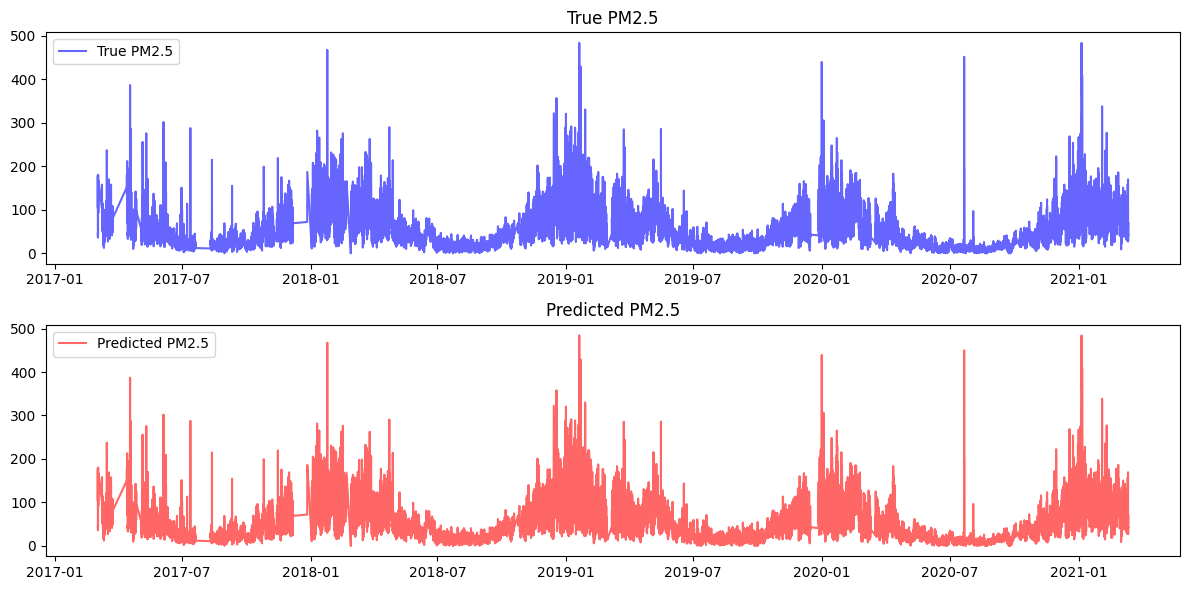

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(x.index, y, label='True PM2.5', color='blue', alpha=0.6)
axes[0].set_title('True PM2.5')
axes[0].legend()

axes[1].plot(x.index, predictions, label='Predicted PM2.5', color='red', alpha=0.6)
axes[1].set_title('Predicted PM2.5')
axes[1].legend()
plt.tight_layout()

In [50]:
train = df["2017-03-03":"2021-03-07"]
test= df["2021-03-08":]
x_train = train.drop(["o3_target","pm25_target","pm25_gap_length","o3_gap_length","o3_missing"],axis=1)
y_train = train["pm25_target"]

x_test = test.drop(["o3_target","pm25_target","pm25_gap_length","o3_gap_length","o3_missing"],axis=1)
y_test = test["pm25_target"]

if "imputation_confidence" in x_train.columns and x_train["imputation_confidence"].dtype == object:
    x_train["imputation_confidence"] = x_train["imputation_confidence"].astype("category")

if "imputation_confidence" in x_test.columns and x_test["imputation_confidence"].dtype == object:
    x_test["imputation_confidence"] = x_test["imputation_confidence"].astype("category")

mask_train = y_train.notna()
x_train = x_train.loc[mask_train]
y_train = y_train.loc[mask_train]    


In [51]:
xgb_model = xgb.XGBRegressor(max_depth=5,
                            n_estimators=100,seed=42,enable_categorical=True)

In [56]:
x_train.shape

(29239, 73)

In [52]:
xgb_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [53]:
pred = xgb_model.predict(x_test)

In [55]:
pred.shape

(121,)